In [1]:
import numpy
print(numpy.__version__)

2.5.1


## Projeto: "Convergência Estatística Aplicada à Precificação de Opções via Modelo Binomial"
Demonstrar empiricamente, através de simulação, como a LFGN, a LGGN e o TLC (via Teorema de De Moivre-Laplace) sustentam o método de precificação de opções por árvore binomial — e quantificar a incerteza da estimativa via Monte Carlo.

In [2]:
import numpy as np
import matplotlib.pyplot as mt
from scipy.stats import binom , norm
import yfinance as yf
import pandas as pd
import requests as rt
import math as M 

Obtenção dos dados que seram usados

In [3]:
dados = yf.download(
    "PETR4.SA",
    period="2y"
)



[*********************100%***********************]  1 of 1 completed


## Modulo  0: preparação e coleta dos dados

Calcular o Log-retorno diario

In [4]:
close  = dados['Close'].squeeze()
razao = close / close.shift(1) # razao entre o fechamento de hoje com o  dia anterior


log = np.log(razao) # calcula o log-retorno diario
log_retorno = log.dropna() 

dp = log_retorno.std() # desvio padrao
dp_anual = dp * np.sqrt(252) # volatilidade anual





print(dp_anual)



0.2454505416572687


Puxando API do banco central

In [5]:
codigo = 11
n = 1
url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados/ultimos/{n}?formato=json'
resposta = rt.get(url)
selic = resposta.json()
r = float(selic[0]['valor']) # Taxa livre de risco



Extraindo os restante dos dados

In [6]:
s0 = close.iat[-1] # Preço Atual da ação
strike = round(s0) # Preço em exercicio, arredondado
T = 0.25 # tempo de vencimento do mercado
n_steps = 200 # Divide em quantos remos vai ter ate a data de vencimento


OUTPUTS

In [7]:

def outputs(vol):
    deltaT = T/n_steps
    u = M.exp(vol * M.sqrt(deltaT))
    d = 1/u
    p = (M.exp(r * deltaT) - d) / (u - d)

    return u,d, p

u, d, p = outputs(dp_anual)

print(u, d, p)


1.0087157500090782 0.991359557924024 0.5016139449957066


Função  simuladora de trajetoria

In [8]:
# Achando o valor de k 

def simulacao(s, P, sub, des, si, K_strike):
    k = np.random.binomial(s, P)
    Sn = si * (sub ** k) * (des ** (s - k))
    payoff = max(Sn - K_strike, 0)

    return Sn, k, payoff

Sn, k, payoff = simulacao(n_steps, p, u, d, s0, strike)

print(Sn, k, payoff)


46.14488451834766 104 3.1448845183476593


## Calculando o preço teorico


In [9]:
esperanca = 0

for k in range(201):
    probk = binom.pmf(k, n_steps, p)  # probabilidade de k altas

    Snk = s0 * (u ** k) * (d ** (n_steps - k))

    payoffk = max(Snk - strike, 0)

    contribuicao = probk * payoffk

    esperanca += contribuicao


def teorico(j, t, e):
    C = np.exp(-j * t) * e
    return C


C = teorico(r, T, esperanca)

print(C)




2.409797678695965


## Modulo 2: Lei Fraca dos Grandes Numeros

# Simulação 

In [10]:

simulacao_N = [10, 100, 1000, 10000]
m_repeticao = 1000

resultados = {}

def estimador_preço(N):
    payoff_N = []

    for m in range(N):
        _, _, pyf= simulacao(n_steps, p, u, d, s0, strike)
        payoff_N.append(float(pyf))

    media_payoff = np.mean(payoff_N)

    Cn = M.exp(-r * T) * media_payoff

    return Cn


for k in simulacao_N:
    Cn_lista = []
    for i in range(m_repeticao):
        cn = estimador_preço(k)
        Cn_lista.append(float(cn))


    resultados[k] = Cn_lista


e = 0.20

margem_erro = {}
for s in simulacao_N:
    v = np.abs(np.array(resultados[s]) - C)
    qtd = np.sum(v > e)

    margem_erro[s] = float(qtd) / 1000
        



print(resultados)
print(margem_erro)






{10: [2.2087911437438312, 3.4318622943654753, 4.676272546307763, 1.436482261411261, 0.38703290777941446, 1.4197291020088392, 2.6905874404337338, 3.323254219344689, 1.0328490210460068, 0.9451176019067524, 4.454987379435491, 2.05317313963261, 3.0454141001960537, 3.945084570862709, 2.316464735852929, 2.9040547855541714, 2.437423643521817, 3.2734745850801272, 2.2386074432862118, 3.919563056866261, 1.0267541015433035, 1.8840811989293107, 4.19964651346412, 3.4052185652429934, 0.948074349250357, 2.528327642069042, 1.668911116135894, 2.387343050053273, 2.0443885340456416, 2.5271538704815857, 2.5556951326168154, 1.730407712961656, 0.2369580061813659, 2.639064102518945, 1.3757752237349379, 3.237307461361405, 1.015824715157451, 0.937096504653298, 2.526693269681586, 2.5573506146406118, 2.078063685492595, 0.5496506205021118, 1.2857412208141177, 3.9376309717519646, 2.233623042766613, 0.7816739364405115, 0.3162789895372058, 1.112170004401847, 4.229056732783741, 1.8017879521393156, 1.2488069753277993,

# Grafico

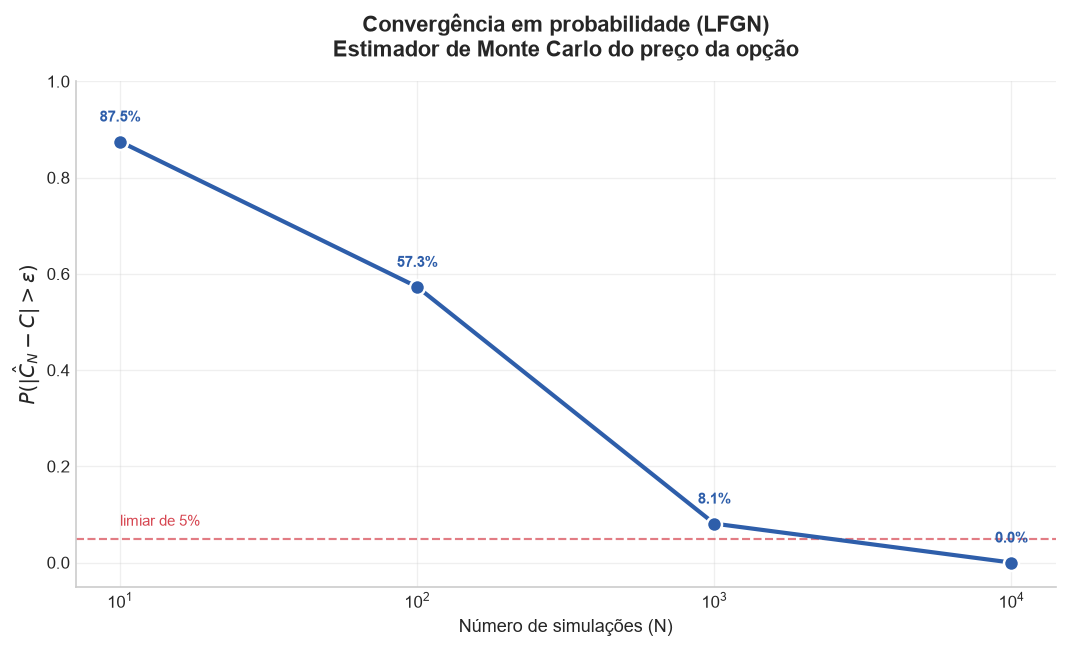

In [13]:
import matplotlib.pyplot as plt

# Estilo geral mais limpo
plt.style.use('seaborn-v0_8-whitegrid')

x = list(margem_erro.keys())
y = list(margem_erro.values())

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

# Linha principal com marcadores maiores e cor customizada
ax.plot(
    x, y,
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='#2E5EAA',
    markerfacecolor='#2E5EAA',
    markeredgecolor='white',
    markeredgewidth=1.5,
    zorder=3
)

# Linha de referência (ex: 5% de erro aceitável)
ax.axhline(y=0.05, color='#D64550', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)
ax.text(x[0], 0.07, 'limiar de 5%', color='#D64550', fontsize=9, va='bottom')

# Anotações com os valores exatos em cada ponto
for xi, yi in zip(x, y):
    ax.annotate(
        f'{yi*100:.1f}%',
        xy=(xi, yi),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#2E5EAA'
    )

ax.set_xscale('log')
ax.set_xlabel('Número de simulações (N)', fontsize=11)
ax.set_ylabel(r'$P(|\hat{C}_N - C| > \varepsilon)$', fontsize=12)
ax.set_title('Convergência em probabilidade (LFGN)\nEstimador de Monte Carlo do preço da opção', fontsize=13, fontweight='bold', pad=15)

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-0.05, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Modulo 2: Lei Forte dos Grandes Numeros

In [ ]:
Xn = []
for z in range(10000):
    _, _, pyf = simulacao(n_steps, p, u, d, s0, strike)
    Xn

